In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import geopandas as gpd
import groupings as gp
import os

path = "C:/Users/damie/OneDrive/UW/research/dargan/projects/energy_emissions/data/visualization/" # path to save image (change if running yourself)

# Load the world map directly from the Natural Earth dataset URL
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
world.index = world["SOVEREIGNT"]
world.loc["France", "ISO_A3"] = "FRA"
world.loc["Norway", "ISO_A3"] = "NOR"

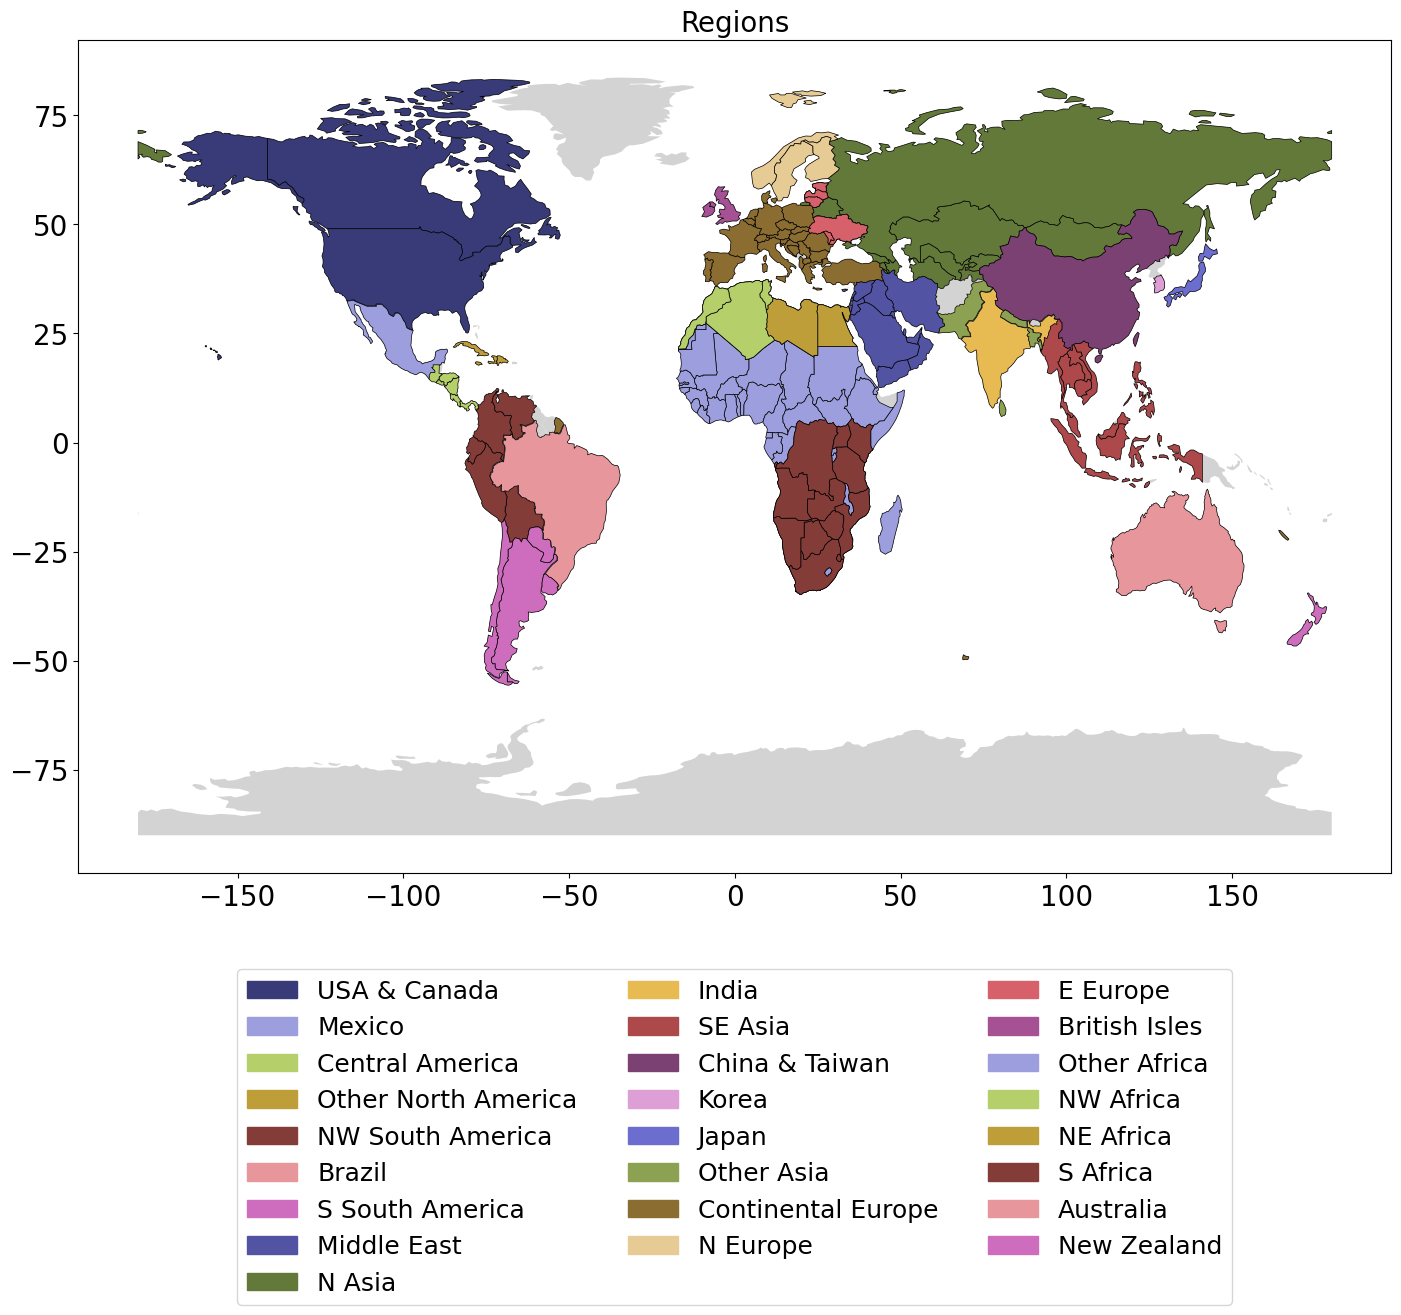

In [ ]:
fig, ax = plt.subplots(figsize=(15, 13))
cmap = plt.get_cmap("tab20b")
world.plot(ax=ax, color="lightgray") 

inc = 3
mod = 20
i = 0
labels = []
legend_patches = []
handles = []

for outer_key, inner_dict in gp.region_aggregations.items():
	for inner_key, region in inner_dict.items():

		# list of ISO3 codes for countries to highlight
		labels.append(inner_key)
		iso3_codes_to_fill = []
		for subregion in region:
			iso3_codes_to_fill = iso3_codes_to_fill + gp.plotting_translator[subregion]

		# create a new column to mark the countries to be filled
		world["highlight"] = world["ISO_A3"].apply(lambda x: 1 if x in iso3_codes_to_fill else 0)

		# plot the map
		plot = world[world["highlight"] == 1].plot(ax=ax,
											                         color=cmap(i % mod),
																							 edgecolor="black",
																							 linewidth=0.5,
																							 label=inner_key) # highlighted countries
		handles.append(plot)
		if (inner_key[-8:] != "Subtract"):
			if inner_key[-3:] == "Add":
				inner_key = inner_key[:-3]
			patch = mpatches.Patch(color=cmap(i % mod),
						                 label=inner_key)
			legend_patches.append(patch)
		i += inc

plt.title("Regions", fontsize = 20)
plt.rcParams["xtick.labelsize"] = 20  # font size for x-axis tick labels
plt.rcParams["ytick.labelsize"] = 20  # font size for y-axis tick labels
plt.legend(handles=legend_patches,
		       loc="upper center",
					 bbox_to_anchor=(0.5, -0.1),
					 ncols=3,
					 fontsize=18) # use patches for legend

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
os.makedirs(path, exist_ok = True)
plt.savefig(path + "region_aggregations.png")